# Comparison of aggregate performance

In [1]:
# data paths
ADM1_PATH = "data/sierra-leone-districts.geojson"
ADM2_PATH = "data/sierra-leone-chiefdoms.geojson"
POPULATION_PATH = "data/population_yearly_sierra_leone_2025.nc"
CLIMATE_PATH = "data/era5-land-monthly-temp-precip-1990-2025-sierra-leone.nc"

# Load raster as xarray
import xarray as xr
clim = xr.open_dataset(CLIMATE_PATH).rename({'longitude': 'x', 'latitude': 'y'})  # shape: (bands, y, x)
clim = clim.t2m.isel(valid_time=slice(30*6))
pop = xr.open_dataset(POPULATION_PATH).drop_vars('spatial_ref')

# Load regions
import geopandas as gpd
adm1s = gpd.read_file(ADM1_PATH)
adm2s = gpd.read_file(ADM2_PATH)

<Axes: >

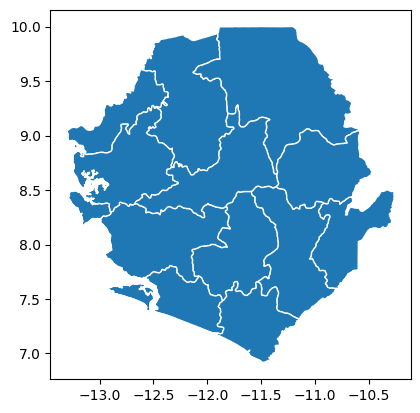

In [2]:
adm1s.plot(edgecolor='white')

<Axes: >

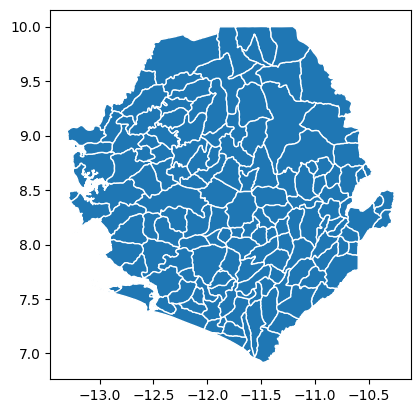

In [3]:
adm2s.plot(edgecolor='white')

## Setup

### Define comparisons

In [4]:
# earthkit method
from earthkit import transforms
def test_earthkit(ds, gdf):
    reduced = transforms.spatial.reduce(ds, gdf, how="mean", lon_key='x', lat_key='y')
    return reduced

In [5]:
# regionmask simple 2d method
import regionmask
def test_regionmask_simple(ds, gdf):
    # Get regions
    regions = regionmask.from_geopandas(gdf, overlap=False) # overlap false allows overlapping regions
    #print(regions)

    # Build binary mask
    mask = regions.mask(ds.x, ds.y)
    print(mask)

    # # Calculate grouped mean
    # # Recommended usage but super slow!
    # region_values = ds.groupby(mask).mean()
    # print(region_values)
    # return region_values

    import numpy as np
    region_ids = np.unique(mask.values)
    results = []
    for rid in region_ids:
        if np.isnan(rid):
            continue
        print(rid)
        region_mask = (mask==rid)
        pop_masked = pop.where(region_mask, drop=True)
        stat = pop_masked.mean(dim=('x', 'y'))
        results.append(stat)
    out_ds = xr.concat(results, dim="region")
    return out_ds

In [6]:
# regionmask simple 3d method
import regionmask
def test_regionmask_3d(ds, gdf):
    # Get regions
    regions = regionmask.from_geopandas(gdf, overlap=False) # overlap false allows overlapping regions
    #print(regions)

    # Build binary mask
    mask = regions.mask_3D(ds.x, ds.y)
    print('mask', mask)

    # Add mask to ds
    ds_with_mask = ds * mask
    print('ds with mask', ds_with_mask)

    # Calculate region means
    region_values = ds_with_mask.mean(dim=('x', 'y'))
    print('region values', region_values)
    
    return region_values

In [7]:
# regionmask fractional method
import regionmask
def test_regionmask_frac(ds, gdf):
    # Get regions
    regions = regionmask.from_geopandas(gdf, overlap=False) # overlap false allows overlapping regions
    #print(regions)

    # Build partial overlap mask cube
    mask_frac = regions.mask_3D_frac_approx(ds.x, ds.y)
    print(mask_frac)

    # Use built-in weighted_mean reducer
    region_values = ds.weighted(mask_frac).mean(dim=('x','y'))
    print(region_values)
    
    return region_values

In [8]:
# xarray-spatial polygonize+zonal_stats
from xrspatial.rasterize import rasterize
from xrspatial import zonal_stats
def test_xrspatial(ds, gdf):
    # TODO: right now just for a single time, need to probably loop through time dims...? 
    mask = rasterize(gdf.reset_index(), 
                     width=len(ds.x.values), 
                     height=len(ds.y.values), 
                     column='index',
                     #all_touched=True,
            )
    print(mask)
    print(ds)
    time_dim = [dim for dim in ds.coords if 'time' in dim][0]
    for t in ds[time_dim].values:
        print('time', t)
        region_values = zonal_stats(mask, ds.sel(**{time_dim: t}), stats_funcs=['mean'])  # .isel(time=0)
    # TODO: need to also merge together resulting dfs for each timestep
    # ... 
    return region_values

#res = test_xrspatial(clim, adm2s)
#res

In [9]:
# exactextract
from exactextract import exact_extract

# def test_exactextract(ds, gdf):
#     da = ds[list(ds.data_vars)[0]]
#     rast = XArrayRasterSource(da)
#     vec = GeoPandasFeatureSource(gdf)
#     print(rast, vec)
#     result_values = exact_extract(rast, vec, ['mean'], output='pandas')
#     print(result_values)
#     return result_values

def test_exactextract(ds, gdf):
    # aggregate
    #gdf = gdf.copy()
    #gdf['id'] = gdf['id'].astype(str)
    #print(gdf)
    #print(gdf.dtypes)
    gdf = gdf[['id', 'geometry']]  # there's some fields that create trouble so need to strip down the fields... 
    df = exact_extract(ds, gdf, ['mean'], include_geom=False, include_cols=['id'], output='pandas', strategy='raster-sequential')
    print(df)
    # 1. reshape wide → long
    df_long = df.melt(id_vars='id', var_name='band', value_name='t2m')
    # 2. extract band index (1-based → 0-based)
    if 'band' in df_long['band']:
        df_long['band'] = df_long['band'].str.extract(r'band_(\d+)_mean').astype(int) - 1
    else:
        df_long['band'] = 0
    # 3. map to time
    time_dim = [dim for dim in ds.coords if 'time' in dim][0]
    df_long[time_dim] = ds[time_dim].values[df_long['band']]
    # 4. optional: drop helper column
    df_long = df_long.drop(columns='band')
    return df_long

# TODO: JUST TEMPORARY FOR QUICK TESTING
#res, peak_mb, duration = measure_perf(test_exactextract, clim, adm1s)
#print('duration', duration, 'memory', peak_mb)
#print(clim)
#res = test_exactextract(clim, adm1s)
#res

In [10]:
# xagg
import xagg
def test_xagg(ds, gdf):
    weightmap = xagg.pixel_overlaps(ds, gdf)
    result_values = xagg.aggregate(ds, weightmap)
    return result_values

In [ ]:
# custom method 1
# custom geospatial method that matches exact desired resolution
# NOT very efficient or fast
def test_custom1(ds, gdf, accuracy = 0.01):
    # accuracy is desired decimal resolution, default ~1 km
    import numpy as np

    # create dummy array with original data shape
    orig_shape = (len(ds.y), len(ds.x))
    orig = xr.DataArray(
        np.zeros(orig_shape, dtype="bool"),
        coords={'y': ds.coords['y'].values, 'x': ds.coords['x'].values},
        dims=('y','x')
    )
    #print('orig', orig)

    # loop geoms
    results = []
    for i,row in gdf.iterrows():
        print(i, '==============================================================================')
        # get mask of coarse pixels that touch geom
        orig_mask = transforms.spatial._aggregate.rasterize(
            [row['geometry']], 
            orig.coords,
            lon_key='x',
            lat_key='y',
            all_touched=True,
        )
        #print('orig mask', orig_mask)

        # trim to 1 values
        def trim_to_mask(mask_da, y_dim="y", x_dim="x"):
            m = mask_da.astype(bool).values
            ys, xs = np.where(m)
            if len(ys) == 0:
                return mask_da.isel({y_dim: slice(0,0), x_dim: slice(0,0)})
            y0, y1 = ys.min(), ys.max()
            x0, x1 = xs.min(), xs.max()
            return mask_da.isel({y_dim: slice(y0, y1+1), x_dim: slice(x0, x1+1)})
        trimmed = trim_to_mask(orig_mask)
        #print('trimmed', trimmed)

        # clip and downscale those pixels to finer
        xmin,ymin = trimmed.x.min().item(), trimmed.y.min().item()
        xmax,ymax = trimmed.x.max().item(), trimmed.y.max().item()
        #print('bbox', xmin,ymin,xmax,ymax)
        new_x = np.arange(xmin, xmax, accuracy)
        new_y = np.arange(ymin, ymax, accuracy)
        shape = (len(new_y), len(new_x))
        fine = xr.DataArray(
            np.zeros(shape, dtype=bool),
            coords={"y": new_y, "x": new_x},
            dims=("y", "x"),
        )
        #print('fine', fine)

        if not all(shape):
            print('fine grid collapsed, skipping!')
            continue

        print('subsampled from', trimmed.shape, 'to', fine.shape)

        # get mask of fine pixels that touch geom
        fine_mask = transforms.spatial._aggregate.rasterize(
            [row['geometry']], 
            fine.coords,
            lon_key='x',
            lat_key='y',
            all_touched=True,
        )
        #print('fine mask', fine_mask)

        # aggregate to coarser grid
        #weights = fine_mask.astype(float).coarsen(x=9, y=9, boundary="trim").mean()
        from rasterio.enums import Resampling
        trimmed.rio.write_crs("EPSG:4326", inplace=True)
        fine_mask.rio.write_crs("EPSG:4326", inplace=True)
        weights = fine_mask.astype(float).rio.reproject_match(trimmed, resampling=Resampling.average)
        #print('weights', weights)
        
        # loop each variable
        for var in ds.data_vars:
            print('-->', var)
            # compute weighted mean
            values = ds[var]
            trimmed_values = values.sel(x=trimmed.x.values, y=trimmed.y.values)
            #print('trimmed vals', trimmed_values)
            weighted_sum = (trimmed_values * weights).sum(dim=("y","x"))
            #print('mult', trimmed_values * weights)
            total_weight = weights.sum(dim=("y","x"))
            #print('weightsum', total_weight)
            geom_mean = weighted_sum / total_weight
            #print('-->', var, geom_mean)
            results.append({'i': i, 'var': var, 'value': geom_mean})
    
    # create output df
    import pandas as pd
    df = pd.DataFrame.from_records(results)
    return df

In [ ]:
# custom method 2
# custom cell-split method which just splits each cell by an integer factor
# eg factor=10, means a single cell is split into 10x10 subpixels
# then rasterizes geometries onto the fine grid
# and finally aggregates the fine grid back to the original resolution based on the factor param
# meaning essentially reverting the split-operation but getting approx number proportion of cell
# that got rasterized by each geometry.
def test_custom2(ds, gdf, factor=10):
    import numpy as np

    # loop geoms
    results = []
    for i,row in gdf.iterrows():
        print(i, '==============================================================================')
    
        # crop ds to geom bbox
        xmin,ymin,xmax,ymax = row['geometry'].bounds
        crop = ds.sel(
            x=slice(xmin, xmax),
            y=slice(ymax, ymin),  # reverse if lat is descending
        )
        #print('crop', crop)

        # divide each cell into n subpixels
        nx = len(crop.x) * factor
        ny = len(crop.y) * factor
        new_x = np.linspace(crop.x.min().item(), crop.x.max().item(), nx)
        new_y = np.linspace(crop.y.min().item(), crop.y.max().item(), ny)
        fine = crop.interp(x=new_x, y=new_y, method="nearest")
        #print('fine', fine)

        # get mask of fine pixels that touch geom
        from earthkit import transforms
        fine_mask = transforms.spatial._aggregate.rasterize(
            [row['geometry']], 
            fine.coords,
            lon_key='x',
            lat_key='y',
            all_touched=True,
        )
        #print('fine mask', fine_mask)

        # compute weights to coarser grid
        weights = fine_mask.astype(float).coarsen(x=factor, y=factor, boundary="trim").mean()
        #print('weights', weights)

        # aggregate values according to weights
        agg = fine.weighted(weights).mean(dim=('x', 'y'))
        #print('agg', agg)

        # TODO: need to add to results for that geometry/feature id
        # ... 
    
    # create output df
    import pandas as pd
    df = pd.DataFrame.from_records(results)
    return df

#res, peak_mb, duration = measure_perf(test_custom2, clim, adm1s)
#print('duration', duration, 'memory', peak_mb)
#res

### Define performance measurements

In [ ]:
# define performance test

import time
#from memory_profiler import memory_usage
import tracemalloc

# def measure_perf(func, *args, **kwargs):
#     start = time.perf_counter()
#     start_mem = memory_usage(max_usage=True)
#     max_mem = memory_usage(proc=(func, args, kwargs), max_usage=True)
#     end = time.perf_counter()
#     used_mem = max_mem - start_mem
#     return used_mem, end - start

def measure_perf(func, *args, **kwargs):
    # tracemalloc
    # not fully sure if consider the memory used by numpy which uses raw C malloc
    # but it actually seems to do so from the results...
    start = time.perf_counter()
    tracemalloc.clear_traces()
    tracemalloc.start()
    res = func(*args, **kwargs)
    cur_mem, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    print(f'(memory bytes {cur_mem} {peak_mem})')
    peak_mem /= 1048576 # bytes to mb
    end = time.perf_counter()
    return res, peak_mem, end - start

# def measure_perf(func, *args, **kwargs):
#     start = time.perf_counter()
#     res = func(*args, **kwargs)
#     end = time.perf_counter()
#     used_mem = 0
#     return res, used_mem, end - start

stats = []

--------------
## Run coarse resolution tests 

In [14]:
clim

<xarray.DataArray 't2m' (valid_time: 180, y: 33, x: 33)> Size: 784kB
[196020 values with dtype=float32]
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 1kB 1990-01-01 ... 2004-12-01
  * y           (y) float64 264B 10.1 10.0 9.9 9.8 9.7 ... 7.3 7.2 7.1 7.0 6.9
  * x           (x) float64 264B -13.4 -13.3 -13.2 -13.1 ... -10.4 -10.3 -10.2
    number      int64 8B ...
    expver      (valid_time) <U4 3kB ...
Attributes: (12/31)
    GRIB_paramId:                             167
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      1089
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

(8.0926, 8.4996)

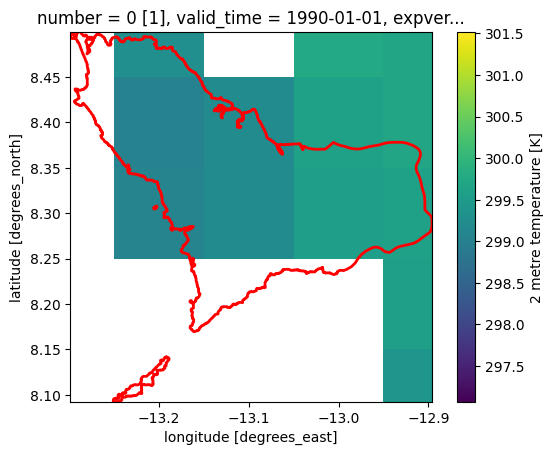

In [15]:
# visualize a single geometry example
import matplotlib.pyplot as plt
ax = plt.subplot()
clim.isel(valid_time=0).plot(ax=ax)
focus = adm1s.query('name=="Western Area"')
focus.plot(ax=ax, color='none', edgecolor='red', linewidth=2)
xmin,ymin,xmax,ymax = focus.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

### Earthkit

In [16]:
# test adm1
res, peak_mb, duration = measure_perf(lambda: test_earthkit(clim, adm1s))
stats.append(dict(method='earthkit', raster='clim', vector='adm1', time=duration, memory=peak_mb))
print(f"Duration: {duration:.2f}s, Peak memory: {peak_mb:.2f} MB")
res.to_dataframe().reset_index()

(memory bytes 1491957 3565443)
Duration: 0.39s, Peak memory: 3.40 MB


,index,valid_time,number,expver,t2m
0,0,1990-01-01,0,0001,299.332855
1,0,1990-02-01,0,0001,300.702026
2,0,1990-03-01,0,0001,301.218048
3,0,1990-04-01,0,0001,300.047180
4,0,1990-05-01,0,0001,298.360992
...,...,...,...,...,...
2335,12,2004-08-01,0,0001,297.602051
2336,12,2004-09-01,0,0001,298.068176
2337,12,2004-10-01,0,0001,298.758240
2338,12,2004-11-01,0,0001,299.302063


In [17]:
# test adm2
res, peak_mb, duration = measure_perf(lambda: test_earthkit(clim, adm2s))
stats.append(dict(method='earthkit', raster='clim', vector='adm2', time=duration, memory=peak_mb))
print(f"Duration: {duration:.2f}s, Peak memory: {peak_mb:.2f} MB")
res.to_dataframe().reset_index()

(memory bytes 522500 3291008)
Duration: 3.34s, Peak memory: 3.14 MB


,index,valid_time,number,expver,t2m
0,0,1990-01-01,0,0001,299.536499
1,0,1990-02-01,0,0001,301.045288
2,0,1990-03-01,0,0001,301.620117
3,0,1990-04-01,0,0001,300.070923
4,0,1990-05-01,0,0001,298.260986
...,...,...,...,...,...
27355,151,2004-08-01,0,0001,297.229279
27356,151,2004-09-01,0,0001,297.613312
27357,151,2004-10-01,0,0001,298.244019
27358,151,2004-11-01,0,0001,298.756042


### Regionmask partial pixels

In [18]:
# test adm1
res, peak_mb, duration = measure_perf(lambda: test_regionmask_frac(clim, adm1s))
stats.append(dict(method='regionmask frac', raster='clim', vector='adm1', time=duration, memory=peak_mb))
print(f"Duration: {duration:.2f}s, Peak memory: {peak_mb:.2f} MB")
res.to_dataframe().reset_index()

<xarray.DataArray 'mask' (region: 13, y: 33, x: 33)> Size: 113kB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
  

,valid_time,region,number,expver,abbrevs,names,t2m
0,1990-01-01,0,0,0001,r0,Region0,299.335618
1,1990-01-01,1,0,0001,r1,Region1,300.732758
2,1990-01-01,2,0,0001,r2,Region2,299.285532
3,1990-01-01,3,0,0001,r3,Region3,299.370572
4,1990-01-01,4,0,0001,r4,Region4,300.189991
...,...,...,...,...,...,...,...
2335,2004-12-01,8,0,0001,r8,Region8,298.833971
2336,2004-12-01,9,0,0001,r9,Region9,299.371670
2337,2004-12-01,10,0,0001,r10,Region10,298.551528
2338,2004-12-01,11,0,0001,r11,Region11,298.386037


In [19]:
# test adm2
res, peak_mb, duration = measure_perf(lambda: test_regionmask_frac(clim, adm2s))
stats.append(dict(method='regionmask frac', raster='clim', vector='adm2', time=duration, memory=peak_mb))
print(f"Duration: {duration:.2f}s, Peak memory: {peak_mb:.2f} MB")
res.to_dataframe().reset_index()

<xarray.DataArray 'mask' (region: 152, y: 33, x: 33)> Size: 1MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
   

,valid_time,region,number,expver,abbrevs,names,t2m
0,1990-01-01,0,0,0001,r0,Region0,299.531505
1,1990-01-01,1,0,0001,r1,Region1,299.158066
2,1990-01-01,2,0,0001,r2,Region2,299.518030
3,1990-01-01,3,0,0001,r3,Region3,299.341317
4,1990-01-01,4,0,0001,r4,Region4,299.142887
...,...,...,...,...,...,...,...
27355,2004-12-01,147,0,0001,r147,Region147,298.390175
27356,2004-12-01,148,0,0001,r148,Region148,298.833601
27357,2004-12-01,149,0,0001,r149,Region149,299.080615
27358,2004-12-01,150,0,0001,r150,Region150,298.312709


### Exactextract

In [20]:
# test adm1
res, peak_mb, duration = measure_perf(lambda: test_exactextract(clim, adm1s))
stats.append(dict(method='exactextract', raster='clim', vector='adm1', time=duration, memory=peak_mb))
print(f"Duration: {duration:.2f}s, Peak memory: {peak_mb:.2f} MB")
res.reset_index()

    id  band_1_mean  band_2_mean  band_3_mean  band_4_mean  band_5_mean  \
0    0   299.335564   300.698113   301.217149   300.062452   298.373888   
1    1   300.732795   301.321780   302.493983   302.809893   300.061859   
2    2   299.285122   299.997658   300.436583   300.279506   299.026275   
3    3   299.369528   300.845149   301.480085   299.788360   298.179871   
4    4   300.191125   300.253799   301.247938   301.823031   300.176672   
5    5   299.212172   300.636675   301.099123   299.638653   298.102945   
6    6   299.466062   300.451507   301.934187   301.232376   298.488705   
7    7   299.268023   300.597159   301.654679   299.730883   297.881586   
8    8   299.330473   300.142203   300.817290   300.581094   298.899240   
9    9   299.808782   300.029704   300.917014   301.316809   299.590409   
10  10   298.926533   300.064940   300.368466   299.695218   298.464624   
11  11   299.586894   300.592691   301.495961   300.855367   298.551382   
12  12   299.290604   299

,index,id,t2m,valid_time
0,0,0,299.335564,1990-01-01
1,1,1,300.732795,1990-01-01
2,2,2,299.285122,1990-01-01
3,3,3,299.369528,1990-01-01
4,4,4,300.191125,1990-01-01
...,...,...,...,...
2335,2335,8,298.834136,1990-01-01
2336,2336,9,299.372910,1990-01-01
2337,2337,10,298.550824,1990-01-01
2338,2338,11,298.386386,1990-01-01


In [21]:
# test adm2
res, peak_mb, duration = measure_perf(lambda: test_exactextract(clim, adm2s))
stats.append(dict(method='exactextract', raster='clim', vector='adm2', time=duration, memory=peak_mb))
print(f"Duration: {duration:.2f}s, Peak memory: {peak_mb:.2f} MB")
res.reset_index()

      id  band_1_mean  band_2_mean  band_3_mean  band_4_mean  band_5_mean  \
0      0   299.523937   301.026300   301.596450   300.061150   298.257141   
1      1   299.158174   299.939071   300.607963   300.445815   298.836637   
2      2   299.518854   300.977895   301.440015   300.024969   298.367915   
3      3   299.337715   300.791331   301.323168   299.941414   298.161812   
4      4   299.143296   300.433667   300.881209   299.997496   298.530373   
..   ...          ...          ...          ...          ...          ...   
147  147   299.237130   300.594959   300.904589   299.696543   298.341345   
148  148   299.051102   300.026167   300.369293   300.082382   298.768703   
149  149   299.232034   300.047889   300.505269   300.318790   298.960232   
150  150   299.692062   301.123974   302.021391   300.285931   298.399778   
151  151   299.734117   300.678293   301.500395   301.239567   299.064665   

     band_6_mean  band_7_mean  band_8_mean  band_9_mean  ...  band_171_mean

,index,id,t2m,valid_time
0,0,0,299.523937,1990-01-01
1,1,1,299.158174,1990-01-01
2,2,2,299.518854,1990-01-01
3,3,3,299.337715,1990-01-01
4,4,4,299.143296,1990-01-01
...,...,...,...,...
27355,27355,147,298.389662,1990-01-01
27356,27356,148,298.832905,1990-01-01
27357,27357,149,299.080236,1990-01-01
27358,27358,150,298.311734,1990-01-01


### Xagg

In [22]:
# test adm1
res, peak_mb, duration = measure_perf(lambda: test_xagg(clim, adm1s))
stats.append(dict(method='xagg', raster='clim', vector='adm1', time=duration, memory=peak_mb))
print(f"Duration: {duration:.2f}s, Peak memory: {peak_mb:.2f} MB")
res.to_dataframe()

creating polygons for each pixel...
lat/lon bounds not found in dataset; they will be created.
calculating overlaps between pixels and output polygons...
success!
aggregating t2m...
all variables aggregated to polygons!
(memory bytes 1541689 3948498)
Duration: 0.70s, Peak memory: 3.77 MB


type           id          name  \
poly_idx valid_time                                            
0        1990-01-01       Polygon  O6uvpzGd5pu            Bo   
         1990-02-01       Polygon  O6uvpzGd5pu            Bo   
         1990-03-01       Polygon  O6uvpzGd5pu            Bo   
         1990-04-01       Polygon  O6uvpzGd5pu            Bo   
         1990-05-01       Polygon  O6uvpzGd5pu            Bo   
...                           ...          ...           ...   
12       2004-08-01  MultiPolygon  at6UHUQatSo  Western Area   
         2004-09-01  MultiPolygon  at6UHUQatSo  Western Area   
         2004-10-01  MultiPolygon  at6UHUQatSo  Western Area   
         2004-11-01  MultiPolygon  at6UHUQatSo  Western Area   
         2004-12-01  MultiPolygon  at6UHUQatSo  Western Area   

                     hasCoordinatesDown  hasCoordinatesUp  level  \
poly_idx valid_time                                                
0        1990-01-01                True             False      2   
         1990-02-01                True             False      2   
         1990-03-01                True             False      2   
         1990-04-01                True             False      2   
         1990-05-01                True             False      2   
...                                 ...               ...    ...   
12       2004-08-01                True             False      2   
         2004-09-01                True             False      2   
         2004-10-01                True             False      2   
         2004-11-01                True             False      2   
         2004-12-01                True             False      2   

                    grandParentParentGraph grandParentId  parentGraph  \
poly_idx valid_time                                                     
0        1990-01-01                                       ImspTQPwCqd   
         1990-02-01                                       ImspTQPwCqd   
         1990-03-01                                       ImspTQPwCqd   
         1990-04-01                                       ImspTQPwCqd   
         1990-05-01                                       ImspTQPwCqd   
...                                    ...           ...          ...   
12       2004-08-01                                       ImspTQPwCqd   
         2004-09-01                                       ImspTQPwCqd   
         2004-10-01                                       ImspTQPwCqd   
         2004-11-01                                       ImspTQPwCqd   
         2004-12-01                                       ImspTQPwCqd   

                        parentId    parentName dimensions  weight         t2m  
poly_idx valid_time                                                            
0        1990-01-01  ImspTQPwCqd  Sierra Leone         {}       1  299.335549  
         1990-02-01  ImspTQPwCqd  Sierra Leone         {}       1  300.698088  
         1990-03-01  ImspTQPwCqd  Sierra Leone         {}       1  301.217082  
         1990-04-01  ImspTQPwCqd  Sierra Leone         {}       1  300.062426  
         1990-05-01  ImspTQPwCqd  Sierra Leone         {}       1  298.373974  
...                          ...           ...        ...     ...         ...  
12       2004-08-01  ImspTQPwCqd  Sierra Leone         {}       1  297.622604  
         2004-09-01  ImspTQPwCqd  Sierra Leone         {}       1  298.086294  
         2004-10-01  ImspTQPwCqd  Sierra Leone         {}       1  298.777509  
         2004-11-01  ImspTQPwCqd  Sierra Leone         {}       1  299.321802  
         2004-12-01  ImspTQPwCqd  Sierra Leone         {}       1  299.575387  

[2340 rows x 14 columns]

In [23]:
# test adm2
res, peak_mb, duration = measure_perf(lambda: test_xagg(clim, adm2s))
stats.append(dict(method='xagg', raster='clim', vector='adm2', time=duration, memory=peak_mb))
print(f"Duration: {duration:.2f}s, Peak memory: {peak_mb:.2f} MB")
res.to_dataframe()

creating polygons for each pixel...
lat/lon bounds not found in dataset; they will be created.
calculating overlaps between pixels and output polygons...
success!
aggregating t2m...
all variables aggregated to polygons!
(memory bytes 1965405 4372463)
Duration: 3.09s, Peak memory: 4.17 MB


type           id    name  hasCoordinatesDown  \
poly_idx valid_time                                                     
0        1990-01-01  Polygon  YuQRtpLP10I  Badjia                True   
         1990-02-01  Polygon  YuQRtpLP10I  Badjia                True   
         1990-03-01  Polygon  YuQRtpLP10I  Badjia                True   
         1990-04-01  Polygon  YuQRtpLP10I  Badjia                True   
         1990-05-01  Polygon  YuQRtpLP10I  Badjia                True   
...                      ...          ...     ...                 ...   
151      2004-08-01  Polygon  NNE0YMCDZkO    Yoni                True   
         2004-09-01  Polygon  NNE0YMCDZkO    Yoni                True   
         2004-10-01  Polygon  NNE0YMCDZkO    Yoni                True   
         2004-11-01  Polygon  NNE0YMCDZkO    Yoni                True   
         2004-12-01  Polygon  NNE0YMCDZkO    Yoni                True   

                     hasCoordinatesUp  level grandParentParentGraph  \
poly_idx valid_time                                                   
0        1990-01-01              True      3                          
         1990-02-01              True      3                          
         1990-03-01              True      3                          
         1990-04-01              True      3                          
         1990-05-01              True      3                          
...                               ...    ...                    ...   
151      2004-08-01              True      3                          
         2004-09-01              True      3                          
         2004-10-01              True      3                          
         2004-11-01              True      3                          
         2004-12-01              True      3                          

                    grandParentId              parentGraph     parentId  \
poly_idx valid_time                                                       
0        1990-01-01   ImspTQPwCqd  ImspTQPwCqd/O6uvpzGd5pu  O6uvpzGd5pu   
         1990-02-01   ImspTQPwCqd  ImspTQPwCqd/O6uvpzGd5pu  O6uvpzGd5pu   
         1990-03-01   ImspTQPwCqd  ImspTQPwCqd/O6uvpzGd5pu  O6uvpzGd5pu   
         1990-04-01   ImspTQPwCqd  ImspTQPwCqd/O6uvpzGd5pu  O6uvpzGd5pu   
         1990-05-01   ImspTQPwCqd  ImspTQPwCqd/O6uvpzGd5pu  O6uvpzGd5pu   
...                           ...                      ...          ...   
151      2004-08-01   ImspTQPwCqd  ImspTQPwCqd/eIQbndfxQMb  eIQbndfxQMb   
         2004-09-01   ImspTQPwCqd  ImspTQPwCqd/eIQbndfxQMb  eIQbndfxQMb   
         2004-10-01   ImspTQPwCqd  ImspTQPwCqd/eIQbndfxQMb  eIQbndfxQMb   
         2004-11-01   ImspTQPwCqd  ImspTQPwCqd/eIQbndfxQMb  eIQbndfxQMb   
         2004-12-01   ImspTQPwCqd  ImspTQPwCqd/eIQbndfxQMb  eIQbndfxQMb   

                    parentName dimensions  weight         t2m  
poly_idx valid_time                                            
0        1990-01-01         Bo         {}       1  299.524009  
         1990-02-01         Bo         {}       1  301.026373  
         1990-03-01         Bo         {}       1  301.596505  
         1990-04-01         Bo         {}       1  300.061194  
         1990-05-01         Bo         {}       1  298.257197  
...                        ...        ...     ...         ...  
151      2004-08-01  Tonkolili         {}       1  297.218643  
         2004-09-01  Tonkolili         {}       1  297.599451  
         2004-10-01  Tonkolili         {}       1  298.231352  
         2004-11-01  Tonkolili         {}       1  298.743588  
         2004-12-01  Tonkolili         {}       1  298.880700  

[27360 rows x 14 columns]

### Custom 1

In [24]:
# test custom 1
#res, peak_mb, duration = measure_perf(lambda: test_custom1(clim, adm1s))
#print(f"Duration: {duration:.2f}s, Peak memory: {peak_mb:.2f} MB")
#res

----------------------------
## Run fine resolution test

(8.0926, 8.4996)

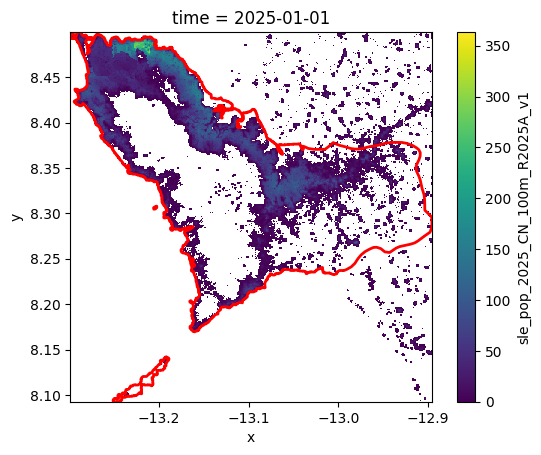

In [25]:
# visualize a single geometry example
import matplotlib.pyplot as plt
ax = plt.subplot()
pop['pop_total'].plot(ax=ax)
focus = adm1s.query('name=="Western Area"')
focus.plot(ax=ax, color='none', edgecolor='red', linewidth=2)
xmin,ymin,xmax,ymax = focus.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

### Earthkit

In [26]:
# test adm1
res, peak_mb, duration = measure_perf(lambda: test_earthkit(pop, adm1s))
stats.append(dict(method='earthkit', raster='pop', vector='adm1', time=duration, memory=peak_mb))
print(f"Duration: {duration:.2f}s, Peak memory: {peak_mb:.2f} MB")
res.to_dataframe().reset_index()

(memory bytes 107744104 457112415)
Duration: 2.48s, Peak memory: 435.94 MB


,index,time,pop_total
0,0,2025-01-01,14.188066
1,1,2025-01-01,7.301537
2,2,2025-01-01,9.954986
3,3,2025-01-01,14.637116
4,4,2025-01-01,7.862771
5,5,2025-01-01,15.563463
6,6,2025-01-01,4.690501
7,7,2025-01-01,9.850505
8,8,2025-01-01,6.046911
9,9,2025-01-01,7.249787


In [27]:
# test adm2
res, peak_mb, duration = measure_perf(lambda: test_earthkit(pop, adm2s))
stats.append(dict(method='earthkit', raster='pop', vector='adm2', time=duration, memory=peak_mb))
print(f"Duration: {duration:.2f}s, Peak memory: {peak_mb:.2f} MB")
res.to_dataframe().reset_index()

(memory bytes 271433 349910044)
Duration: 25.13s, Peak memory: 333.70 MB


,index,time,pop_total
0,0,2025-01-01,13.542968
1,1,2025-01-01,6.755866
2,2,2025-01-01,11.020636
3,3,2025-01-01,7.664399
4,4,2025-01-01,9.972415
...,...,...,...
147,147,2025-01-01,14.469939
148,148,2025-01-01,9.119979
149,149,2025-01-01,6.615936
150,150,2025-01-01,12.519447


### Regionmask simple

Note: Here the pixels are so small that we use the simple method instead of partial pixel fraction method

In [28]:
# test adm1
res, peak_mb, duration = measure_perf(lambda: test_regionmask_simple(pop, adm1s))
stats.append(dict(method='regionmask 2d', raster='pop', vector='adm1', time=duration, memory=peak_mb))
print(f"Duration: {duration:.2f}s, Peak memory: {peak_mb:.2f} MB")
res.to_dataframe().reset_index()

<xarray.DataArray 'mask' (y: 3695, x: 3635)> Size: 107MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(3695, 3635))
Coordinates:
  * y        (y) float64 30kB 10.0 9.999 9.998 9.997 ... 6.924 6.923 6.922 6.921
  * x        (x) float64 29kB -13.3 -13.3 -13.3 -13.3 ... -10.27 -10.27 -10.27
Attributes:
    standard_name:  region
    flag_values:    [ 0  1  2  3  4  5  6  7  8  9 10 11 12]
    flag_meanings:  r0 r1 r2 r3 r4 r5 r6 r7 r8 r9 r10 r11 r12
0.0
1.0
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0
10.0
11.0
12.0
(memory bytes 295091 671878434)
Duration: 1.39s, Peak memory: 640.75 MB


,region,time,pop_total
0,0,2025-01-01,14.188066
1,1,2025-01-01,7.301537
2,2,2025-01-01,9.954986
3,3,2025-01-01,14.637116
4,4,2025-01-01,7.862771
5,5,2025-01-01,15.563463
6,6,2025-01-01,4.690501
7,7,2025-01-01,9.850505
8,8,2025-01-01,6.046911
9,9,2025-01-01,7.249787


In [29]:
# test adm2
res, peak_mb, duration = measure_perf(lambda: test_regionmask_simple(pop, adm2s))
stats.append(dict(method='regionmask 2d', raster='pop', vector='adm2', time=duration, memory=peak_mb))
print(f"Duration: {duration:.2f}s, Peak memory: {peak_mb:.2f} MB")
res.to_dataframe().reset_index()

<xarray.DataArray 'mask' (y: 3695, x: 3635)> Size: 107MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(3695, 3635))
Coordinates:
  * y        (y) float64 30kB 10.0 9.999 9.998 9.997 ... 6.924 6.923 6.922 6.921
  * x        (x) float64 29kB -13.3 -13.3 -13.3 -13.3 ... -10.27 -10.27 -10.27
Attributes:
    standard_name:  region
    flag_values:    [  0   1   2   3   4   5   6   7   8   9  10  11  12  13 ...
    flag_meanings:  r0 r1 r2 r3 r4 r5 r6 r7 r8 r9 r10 r11 r12 r13 r14 r15 r16...
0.0
1.0
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0
10.0
11.0
12.0
13.0
14.0
15.0
16.0
17.0
18.0
19.0
20.0
21.0
22.0
23.0
24.0
25.0
26.0
27.0
28.0
29.0
30.0
31.0
32.0
33.0
34.0
35.0
36.0
37.0
38.0
39.0
40.0
41.0
42.0
43.0
44.0
45.0
46.0
47.0
48.0
49.0
50.0
51.0
52.0
53.0
54.0
55.0
56

,region,time,pop_total
0,0,2025-01-01,13.542968
1,1,2025-01-01,6.755866
2,2,2025-01-01,11.020636
3,3,2025-01-01,7.664399
4,4,2025-01-01,9.972415
...,...,...,...
147,147,2025-01-01,14.469939
148,148,2025-01-01,9.119979
149,149,2025-01-01,6.615936
150,150,2025-01-01,12.519447


### Regionmask 3d

In [30]:
# test adm1
res, peak_mb, duration = measure_perf(lambda: test_regionmask_3d(pop, adm1s))
stats.append(dict(method='regionmask 3d', raster='pop', vector='adm1', time=duration, memory=peak_mb))
print(f"Duration: {duration:.2f}s, Peak memory: {peak_mb:.2f} MB")
res.to_dataframe().reset_index()

mask <xarray.DataArray 'mask' (region: 13, y: 3695, x: 3635)> Size: 175MB
array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
...
        [False, False, F

,time,region,abbrevs,names,pop_total
0,2025-01-01,0,r0,Region0,1.104327
1,2025-01-01,1,r1,Region1,0.801086
2,2025-01-01,2,r2,Region2,0.443275
3,2025-01-01,3,r3,Region3,0.768339
4,2025-01-01,4,r4,Region4,0.514385
5,2025-01-01,5,r5,Region5,1.077646
6,2025-01-01,6,r6,Region6,0.521022
7,2025-01-01,7,r7,Region7,0.871196
8,2025-01-01,8,r8,Region8,0.475148
9,2025-01-01,9,r9,Region9,0.871988


In [31]:
# test adm2
stats.append(dict(method='regionmask 3d', raster='pop', vector='adm2', time=float('nan'), memory=float('nan')))
# BELOW RESULTS IN MEMORY ERROR SO SKIPPING FOR NOW
#res, peak_mb, duration = measure_perf(lambda: test_regionmask_3d(pop, adm2s))
#print(f"Duration: {duration:.2f}s, Peak memory: {peak_mb:.2f} MB")
#res.to_dataframe().reset_index()

### Regionmask partial overlap

In [32]:
# test adm1
#res, peak_mb, duration = measure_perf(lambda: test_regionmask_frac(pop, adm1s))
#stats.append(dict(method='regionmask frac', raster='pop', vector='adm1', time=duration, memory=peak_mb))
#print(f"Duration: {duration:.2f}s, Peak memory: {peak_mb:.2f} MB")
#res.to_dataframe().reset_index()

In [33]:
# test adm2
#res, peak_mb, duration = measure_perf(lambda: test_regionmask_frac(pop, adm2s))
#stats.append(dict(method='regionmask frac', raster='pop', vector='adm2', time=duration, memory=peak_mb))
#print(f"Duration: {duration:.2f}s, Peak memory: {peak_mb:.2f} MB")
#res.to_dataframe().reset_index()

### xarray-spatial

In [ ]:
# test adm1
res, peak_mb, duration = measure_perf(lambda: test_xrspatial(pop, adm1s))
stats.append(dict(method='xrspatial', raster='pop', vector='adm1', time=duration, memory=peak_mb))
print(f"Duration: {duration:.2f}s, Peak memory: {peak_mb:.2f} MB")
res.reset_index()

<xarray.DataArray 'rasterize' (y: 3695, x: 3635)> Size: 107MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(3695, 3635))
Coordinates:
  * y        (y) float64 30kB 10.0 9.999 9.998 9.997 ... 6.921 6.92 6.919 6.918
  * x        (x) float64 29kB -13.3 -13.3 -13.3 -13.3 ... -10.27 -10.27 -10.27
<xarray.Dataset> Size: 108MB
Dimensions:    (time: 1, y: 3695, x: 3635)
Coordinates:
  * time       (time) datetime64[ns] 8B 2025-01-01
  * y          (y) float64 30kB 10.0 9.999 9.998 9.997 ... 6.923 6.922 6.921
  * x          (x) float64 29kB -13.3 -13.3 -13.3 -13.3 ... -10.27 -10.27 -10.27
Data variables:
    pop_total  (time, y, x) float64 107MB nan nan nan nan ... nan nan nan nan
time 2025-01-01T00:00:00.000000000
(memory bytes 169343 511950545)
Duration: 0.44

,index,zone,pop_total_mean
0,0,0.0,14.173109
1,1,1.0,7.243124
2,2,2.0,10.076054
3,3,3.0,14.611725
4,4,4.0,7.889895
5,5,5.0,15.573484
6,6,6.0,4.696867
7,7,7.0,9.888455
8,8,8.0,6.008038
9,9,9.0,7.219887


In [35]:
# test adm2
res, peak_mb, duration = measure_perf(lambda: test_xrspatial(pop, adm2s))
stats.append(dict(method='xrspatial', raster='pop', vector='adm2', time=duration, memory=peak_mb))
print(f"Duration: {duration:.2f}s, Peak memory: {peak_mb:.2f} MB")
res.reset_index()

<xarray.DataArray 'rasterize' (y: 3695, x: 3635)> Size: 107MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(3695, 3635))
Coordinates:
  * y        (y) float64 30kB 10.0 9.999 9.998 9.997 ... 6.921 6.92 6.919 6.918
  * x        (x) float64 29kB -13.3 -13.3 -13.3 -13.3 ... -10.27 -10.27 -10.27
<xarray.Dataset> Size: 108MB
Dimensions:    (time: 1, y: 3695, x: 3635)
Coordinates:
  * time       (time) datetime64[ns] 8B 2025-01-01
  * y          (y) float64 30kB 10.0 9.999 9.998 9.997 ... 6.923 6.922 6.921
  * x          (x) float64 29kB -13.3 -13.3 -13.3 -13.3 ... -10.27 -10.27 -10.27
Data variables:
    pop_total  (time, y, x) float64 107MB nan nan nan nan ... nan nan nan nan
time 2025-01-01T00:00:00.000000000
(memory bytes 170884 511958051)
Duration: 0.66

,index,zone,pop_total_mean
0,0,0.0,13.433644
1,1,1.0,6.738484
2,2,2.0,10.945190
3,3,3.0,7.491378
4,4,4.0,10.222419
...,...,...,...
147,147,147.0,14.287937
148,148,148.0,8.973152
149,149,149.0,6.683118
150,150,150.0,12.239359


### exactextract

In [36]:
# test adm1
res, peak_mb, duration = measure_perf(lambda: test_exactextract(pop, adm1s))
stats.append(dict(method='exactextract', raster='pop', vector='adm1', time=duration, memory=peak_mb))
print(f"Duration: {duration:.2f}s, Peak memory: {peak_mb:.2f} MB")
res.reset_index()

    id       mean
0    0  14.187955
1    1   7.300400
2    2   9.954433
3    3  14.634954
4    4   7.864610
5    5  15.566792
6    6   4.690274
7    7   9.851573
8    8   6.047270
9    9   7.251671
10  10  14.231287
11  11   8.420302
12  12  31.897198
(memory bytes 563100 108280089)
Duration: 0.65s, Peak memory: 103.26 MB


,index,id,t2m,time
0,0,0,14.187955,2025-01-01
1,1,1,7.300400,2025-01-01
2,2,2,9.954433,2025-01-01
3,3,3,14.634954,2025-01-01
4,4,4,7.864610,2025-01-01
5,5,5,15.566792,2025-01-01
6,6,6,4.690274,2025-01-01
7,7,7,9.851573,2025-01-01
8,8,8,6.047270,2025-01-01
9,9,9,7.251671,2025-01-01


In [37]:
# test adm2
res, peak_mb, duration = measure_perf(lambda: test_exactextract(pop, adm2s))
stats.append(dict(method='exactextract', raster='pop', vector='adm2', time=duration, memory=peak_mb))
print(f"Duration: {duration:.2f}s, Peak memory: {peak_mb:.2f} MB")
res.reset_index()

      id       mean
0      0  13.541210
1      1   6.759060
2      2  11.007906
3      3   7.670594
4      4  10.007740
..   ...        ...
147  147  14.473374
148  148   9.107882
149  149   6.626837
150  150  12.506322
151  151   7.637732

[152 rows x 2 columns]
(memory bytes 210087 107801639)
Duration: 0.76s, Peak memory: 102.81 MB


,index,id,t2m,time
0,0,0,13.541210,2025-01-01
1,1,1,6.759060,2025-01-01
2,2,2,11.007906,2025-01-01
3,3,3,7.670594,2025-01-01
4,4,4,10.007740,2025-01-01
...,...,...,...,...
147,147,147,14.473374,2025-01-01
148,148,148,9.107882,2025-01-01
149,149,149,6.626837,2025-01-01
150,150,150,12.506322,2025-01-01


-----------
## Results

In [38]:
import gc
gc.collect()

24438

In [39]:
import pandas as pd
df = pd.DataFrame.from_records(stats)
df[df['raster']=='clim']

,method,raster,vector,time,memory
0,earthkit,clim,adm1,0.389034,3.400271
1,earthkit,clim,adm2,3.340150,3.138550
2,regionmask frac,clim,adm1,0.139492,7.177549
3,regionmask frac,clim,adm2,0.224638,33.553905
4,exactextract,clim,adm1,2.861348,1.503065
5,exactextract,clim,adm2,3.070659,2.914061
6,xagg,clim,adm1,0.697964,3.765581
7,xagg,clim,adm2,3.089118,4.169906


In [40]:
df[df['raster']=='pop']

,method,raster,vector,time,memory
8,earthkit,pop,adm1,2.482392,435.936370
9,earthkit,pop,adm2,25.132810,333.700222
10,regionmask 2d,pop,adm1,1.389910,640.753206
11,regionmask 2d,pop,adm2,8.356427,640.792370
12,regionmask 3d,pop,adm1,2.351009,3164.216381
13,regionmask 3d,pop,adm2,NaN,NaN
14,xrspatial,pop,adm1,3.794824,506.054546
15,xrspatial,pop,adm2,0.663282,488.241244
16,exactextract,pop,adm1,0.651175,103.263940
17,exactextract,pop,adm2,0.763522,102.807654
